# Mini Project 4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Part 1 Know Your Data

In [2]:
ratings_df = pd.read_csv("ratings.csv")
movies_df = pd.read_csv("movies.csv")

In [3]:
display(ratings_df.head())
display(movies_df.head())

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
display(ratings_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


None

In [5]:
display(movies_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


None

In [6]:
ratings_df['timestamp'] = pd.to_datetime(ratings_df['timestamp'], unit='s')

Text(0, 0.5, 'Frequency')

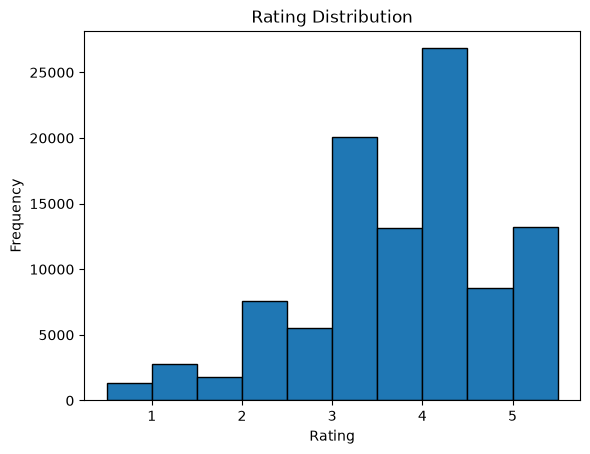

In [7]:
# rating distribution
plt.figure()
plt.hist(ratings_df['rating'], bins=np.arange(0.5, 6, 0.5), edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')

In [8]:
# Per user average rating
ratings_df.groupby('userId')['rating'].mean()

userId
1      4.366379
2      3.948276
3      2.435897
4      3.555556
5      3.636364
         ...   
606    3.657399
607    3.786096
608    3.134176
609    3.270270
610    3.688556
Name: rating, Length: 610, dtype: float64

In [9]:
# Per user max rating
ratings_df.groupby('userId')['rating'].max()

userId
1      5.0
2      5.0
3      5.0
4      5.0
5      5.0
      ... 
606    5.0
607    5.0
608    5.0
609    4.0
610    5.0
Name: rating, Length: 610, dtype: float64

In [10]:
# Per user min rating
ratings_df.groupby('userId')['rating'].min()

userId
1      1.0
2      2.0
3      0.5
4      1.0
5      1.0
      ... 
606    0.5
607    1.0
608    0.5
609    3.0
610    0.5
Name: rating, Length: 610, dtype: float64

In [11]:
# Per user median rating
ratings_df.groupby('userId')['rating'].median()

userId
1      5.0
2      4.0
3      0.5
4      4.0
5      4.0
      ... 
606    4.0
607    4.0
608    3.0
609    3.0
610    3.5
Name: rating, Length: 610, dtype: float64

In [12]:
# Per movie average rating
ratings_df.groupby('movieId')['rating'].mean()

movieId
1         3.920930
2         3.431818
3         3.259615
4         2.357143
5         3.071429
            ...   
193581    4.000000
193583    3.500000
193585    3.500000
193587    3.500000
193609    4.000000
Name: rating, Length: 9724, dtype: float64

In [13]:
# Per movie max rating
ratings_df.groupby('movieId')['rating'].max()

movieId
1         5.0
2         5.0
3         5.0
4         3.0
5         5.0
         ... 
193581    4.0
193583    3.5
193585    3.5
193587    3.5
193609    4.0
Name: rating, Length: 9724, dtype: float64

In [14]:
# per movie min rating
ratings_df.groupby('movieId')['rating'].min()

movieId
1         0.5
2         0.5
3         0.5
4         1.0
5         0.5
         ... 
193581    4.0
193583    3.5
193585    3.5
193587    3.5
193609    4.0
Name: rating, Length: 9724, dtype: float64

In [15]:
# Per movie median rating
ratings_df.groupby('movieId')['rating'].median()

movieId
1         4.0
2         3.5
3         3.0
4         3.0
5         3.0
         ... 
193581    4.0
193583    3.5
193585    3.5
193587    3.5
193609    4.0
Name: rating, Length: 9724, dtype: float64

In [16]:
# Top 10 movies by average rating (with at least 50 ratings)
movie_stats = ratings_df.groupby('movieId')['rating'].agg(['mean', 'count'])
popular_movies = movie_stats[movie_stats['count'] >= 50]
top_10_movies = popular_movies.sort_values(by='mean', ascending=False).head(10)
top_10_movies = top_10_movies.merge(movies_df, left_index=True, right_on='movieId')
display(top_10_movies[['title', 'mean', 'count']])

,title,mean,count
277,"Shawshank Redemption, The (1994)",4.429022,317
659,"Godfather, The (1972)",4.289062,192
2226,Fight Club (1999),4.272936,218
975,Cool Hand Luke (1967),4.271930,57
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
686,Rear Window (1954),4.261905,84
922,"Godfather: Part II, The (1974)",4.259690,129
6315,"Departed, The (2006)",4.252336,107
914,Goodfellas (1990),4.250000,126
694,Casablanca (1942),4.240000,100


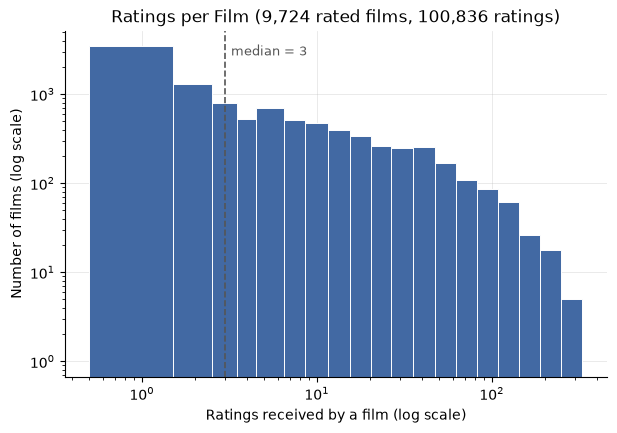

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64

In [17]:
# Distribution of ratings per film (log-log: the counts are heavy-tailed)
ratings_per_film = ratings_df.groupby('movieId').size()

# Log-spaced bins, since counts span 1 -> 329 and pile up hard at the low end.
# Edges are snapped to half-integers so each bin holds a whole number of counts
# (plain logspace edges alias against the integer data and look jagged).
edges = np.unique(np.round(np.logspace(0, np.log10(ratings_per_film.max()), 22)))
bins = np.append(edges - 0.5, ratings_per_film.max() + 0.5)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(ratings_per_film, bins=bins, color='#4269a3', edgecolor='white', linewidth=0.7)
ax.set_xscale('log')
ax.set_yscale('log')

ax.axvline(ratings_per_film.median(), color='#555555', linestyle='--', linewidth=1.2)
ax.annotate(f'median = {ratings_per_film.median():.0f}',
            xy=(ratings_per_film.median(), ax.get_ylim()[1]),
            xytext=(4, -10), textcoords='offset points',
            ha='left', va='top', fontsize=9, color='#555555')

ax.set_title(f'Ratings per Film ({len(ratings_per_film):,} rated films, '
             f'{ratings_per_film.sum():,} ratings)')
ax.set_xlabel('Ratings received by a film (log scale)')
ax.set_ylabel('Number of films (log scale)')
ax.grid(True, which='major', alpha=0.3, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

display(ratings_per_film.describe())


What does the shape of this data imply for a recommender? Which users and
films will be hardest to predict, and why? 

Generally, users tend to rate movies quite highly, however most movies only have a few ratings (median 3). Films with few ratings and users who rate few films will be hard to predict for.

## Part 2 Baselines

Three deliberately dumb predictors, to establish what any SVD result has to beat:

- **Global mean** — predict the same number, $\mu$, for every (user, film) pair.
- **User mean** — predict $\bar r_u$, how generously that subscriber rates in general.
- **Item mean** — predict $\bar r_i$, how well that film is generally received.

All three are fit on the training split only, and the test ratings are touched exactly once,
to score.


In [18]:
# --- Train / test split -------------------------------------------------------
RANDOM_SEED = 42
TEST_FRACTION = 0.20

rng = np.random.default_rng(RANDOM_SEED)
perm = rng.permutation(len(ratings_df))
n_test = int(round(TEST_FRACTION * len(ratings_df)))

test_df  = ratings_df.iloc[perm[:n_test]].reset_index(drop=True)
train_df = ratings_df.iloc[perm[n_test:]].reset_index(drop=True)

print(f'train: {len(train_df):,} ratings   test: {len(test_df):,} ratings')


train: 80,669 ratings   test: 20,167 ratings


In [19]:
# Fit the three baselines. Every quantity here comes from train_df only.
global_mean  = train_df['rating'].mean()
user_means   = train_df.groupby('userId')['rating'].mean()
item_means   = train_df.groupby('movieId')['rating'].mean()
item_support = train_df.groupby('movieId').size()   # ratings backing each item mean


def rmse(y_true, y_pred):
    """Root mean squared error between two equal-length arrays of ratings."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


n_users, n_films = ratings_df['userId'].nunique(), ratings_df['movieId'].nunique()
print(f'global mean (train only) : {global_mean:.4f}')
print(f'users seen in training   : {len(user_means):,} of {n_users:,}')
print(f'films seen in training   : {len(item_means):,} of {n_films:,} '
      f'({n_films - len(item_means):,} films appear only in the test set)')


global mean (train only) : 3.5016
users seen in training   : 610 of 610
films seen in training   : 8,996 of 9,724 (728 films appear only in the test set)


In [20]:
# Score all three on the held-out set. Test ratings are touched here and nowhere else.
y_test = test_df['rating'].to_numpy()

# Unseen user or unseen film -> fall back to the training global mean (justified below).
pred_global = np.full(len(test_df), global_mean)
pred_user   = test_df['userId'].map(user_means).fillna(global_mean).to_numpy()
pred_item   = test_df['movieId'].map(item_means).fillna(global_mean).to_numpy()

baseline_rmse = {
    'Global mean': rmse(y_test, pred_global),
    'User mean':   rmse(y_test, pred_user),
    'Item mean':   rmse(y_test, pred_item),
}

results = pd.DataFrame({'Test RMSE': pd.Series(baseline_rmse)})
results['RMSE reduction vs global mean'] = (
    1 - results['Test RMSE'] / baseline_rmse['Global mean']
).map('{:+.1%}'.format)
display(results.round(4))

best_baseline = min(baseline_rmse, key=baseline_rmse.get)
best_baseline_rmse = baseline_rmse[best_baseline]
print(f'Best baseline to beat: {best_baseline} at RMSE {baseline_rmse[best_baseline]:.4f}')


,Test RMSE,RMSE reduction vs global mean
Global mean,1.0456,+0.0%
User mean,0.9422,+9.9%
Item mean,0.9754,+6.7%


Best baseline to beat: User mean at RMSE 0.9422


In [21]:
# Diagnostic: the item mean is only as good as the number of ratings behind it.
support = test_df['movieId'].map(item_support)   # NaN => film unseen in training
cold = support.isna().to_numpy()

print(f'Test ratings on films with NO training ratings: {cold.sum():,} '
      f'({cold.mean():.1%} of the test set, '
      f'{test_df.loc[cold, "movieId"].nunique():,} distinct films)')
print(f'  item-mean RMSE on those rows (falls back to mu): {rmse(y_test[cold], pred_item[cold]):.4f}')
print(f'  item-mean RMSE on the remaining rows          : {rmse(y_test[~cold], pred_item[~cold]):.4f}')
print(f'  user-mean RMSE on those same cold rows        : {rmse(y_test[cold], pred_user[cold]):.4f}')

# RMSE by how much training data backs each film's mean
rows = [{'film train ratings': '0 (unseen)',
         'test rows': int(cold.sum()),
         'item-mean RMSE': rmse(y_test[cold], pred_item[cold]),
         'user-mean RMSE': rmse(y_test[cold], pred_user[cold])}]
for lo, hi in [(1, 1), (2, 5), (6, 20), (21, 50), (51, 10**9)]:
    m = ((support >= lo) & (support <= hi)).to_numpy()
    rows.append({'film train ratings': f'{lo}-{"inf" if hi > 10**8 else hi}',
                 'test rows': int(m.sum()),
                 'item-mean RMSE': rmse(y_test[m], pred_item[m]),
                 'user-mean RMSE': rmse(y_test[m], pred_user[m])})

display(pd.DataFrame(rows).set_index('film train ratings').round(4))


Test ratings on films with NO training ratings: 798 (4.0% of the test set, 728 distinct films)
  item-mean RMSE on those rows (falls back to mu): 1.1196
  item-mean RMSE on the remaining rows          : 0.9690
  user-mean RMSE on those same cold rows        : 0.9601


,test rows,item-mean RMSE,user-mean RMSE
film train ratings,,,
0 (unseen),798,1.1196,0.9601
1-1,579,1.3007,0.9494
2-5,1953,1.0571,0.9905
6-20,4709,0.9649,0.9321
21-50,5507,0.9563,0.9281
51-inf,6621,0.9199,0.9435


### What the baselines say

| Predictor | Test RMSE | vs global mean |
|---|---|---|
| Global mean (3.5016) | 1.0456 | — |
| User mean | **0.9422** | −9.9% |
| Item mean | 0.9754 | −6.7% |

**The best baseline to beat is the user mean, at RMSE 0.9422.** Any later SVD result has to be
compared against that number, not against the global mean — beating the global mean is trivial.

**Films with no training ratings.** 798 test ratings (4.0% of the test set, spread over 728
distinct films) belong to films that appear nowhere in the training split, so no item mean
exists for them. We predict the **training global mean μ = 3.5016** for those. The
justification: with zero information about a film, the constant that minimises expected
squared error is the mean of the rating distribution, and μ is our only unbiased estimate of
it. Predicting 0, or dropping those rows, would both be wrong — dropping them would quietly
score the model on an easier test set than the one we were given, and it is exactly the
sparse films we most need to be honest about.


**Why the item mean loses to the user mean.** Not because film quality matters less than
user generosity — it is a support problem. Broken down by how many training ratings back
each film's mean:

| Film's train ratings | Test rows | Item-mean RMSE | User-mean RMSE |
|---|---|---|---|
| 0 (unseen) | 798 | 1.1196 | 0.9601 |
| 1 | 579 | 1.3007 | 0.9494 |
| 2–5 | 1,953 | 1.0571 | 0.9905 |
| 6–20 | 4,709 | 0.9649 | 0.9321 |
| 21–50 | 5,507 | 0.9563 | 0.9281 |
| 51+ | 6,621 | **0.9199** | 0.9435 |

On well-observed films the item mean is the **better** predictor (0.9199 vs 0.9435) — film
identity really does carry more signal than user identity once you can estimate it. It loses
overall only because 16.5% of the test set (3,330 rows) sits on films with ≤5 training
ratings, where a mean over one or two ratings is almost pure noise: on single-rating films the
item mean scores 1.3007, *worse* than the 1.0906 the global mean gets on those same rows. An
estimate built from one observation is not weak, it is actively harmful.

This is the argument for the regularised bias model in Part 4: shrinking each film's mean
toward μ in proportion to how little data supports it should capture the 51+ column's
advantage without paying the 1-rating column's penalty. It is also why the ratings-per-film
histogram above matters — that heavy tail is not a curiosity, it is where the error lives.


## Part 3 A first SVD attempt

In [22]:
all_users = np.sort(ratings_df['userId'].unique())
all_films = np.sort(ratings_df['movieId'].unique())

# Pivot the TRAINING ratings only -> 610 x 9724, NaN wherever unobserved
R = train_df.pivot(index='userId', columns='movieId', values='rating')
R = R.reindex(index=all_users, columns=all_films)

# Fill each gap with that film's training mean; films with no training ratings at all have no mean, so they fall back to mu (same rule as Part 2)
col_fill = item_means.reindex(all_films).fillna(global_mean)
R_filled = R.fillna(col_fill)

# Then subtract each user's mean (over their observed training ratings)
A = R_filled.sub(user_means.reindex(all_users), axis=0)

In [23]:
# Calculate the SVD of the centered matrix A. The result is a full SVD, but we will only use the first k columns of U and V^T.
U, s, VT = np.linalg.svd(A, full_matrices=False)

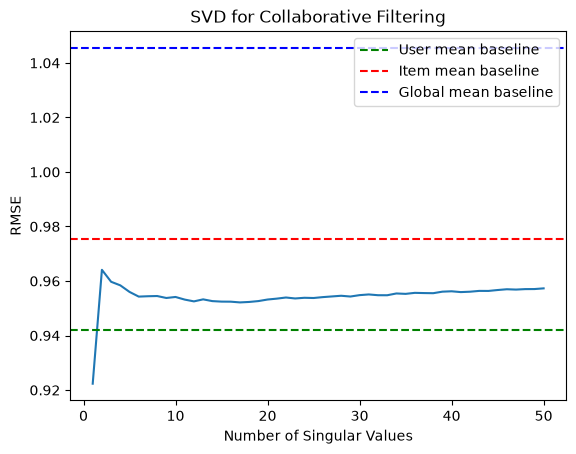

In [24]:
# plot RMSE against k (number of singular values used)
k_values = np.arange(1, 51)
rmse_values = []
for k in k_values:
    # Reconstruct the matrix using the first k singular values
    A_k = U[:, :k] @ np.diag(s[:k]) @ VT[:k, :]
    
    # Add back the user means to get predicted ratings
    R_pred = pd.DataFrame(
        A_k + user_means.reindex(all_users).to_numpy()[:, None],
        index=all_users,
        columns=all_films
    )
    
    # Evaluate RMSE on the test set
    pred_test = test_df.apply(lambda row: R_pred.at[row['userId'], row['movieId']], axis=1)
    rmse_values.append(rmse(y_test, pred_test))

plt.plot(k_values, rmse_values)
plt.axhline(baseline_rmse['User mean'], color='g', linestyle='--', label='User mean baseline')
plt.axhline(baseline_rmse['Item mean'], color='r', linestyle='--', label='Item mean baseline')
plt.axhline(baseline_rmse['Global mean'], color='b', linestyle='--', label='Global mean baseline')
plt.legend()
plt.xlabel('Number of Singular Values')
plt.ylabel('RMSE')
plt.title('SVD for Collaborative Filtering')
plt.show()

In [25]:
# How much energy does k = 1 capture?
energy_k1 = s[0]**2 / np.sum(s**2)
print(f'Energy captured by k=1: {energy_k1:.4%}')

Energy captured by k=1: 82.3387%


## Part 4. Do it Properly

In [26]:
# fit a regularized bias model (starting with lambda = 10)
LAMBDA = 10.0

deviation = train_df['rating'] - global_mean

# Item bias first
g = deviation.groupby(train_df['movieId'])
b_i = (g.sum() / (LAMBDA + g.size())).reindex(all_films).fillna(0.0)

# Then user bias, against what the item bias leaves behind
resid = deviation - train_df['movieId'].map(b_i)
g = resid.groupby(train_df['userId'])
b_u = (g.sum() / (LAMBDA + g.size())).reindex(all_users).fillna(0.0)

# Predict
pred_bias = (global_mean
             + test_df['userId'].map(b_u).fillna(0.0).to_numpy()
             + test_df['movieId'].map(b_i).fillna(0.0).to_numpy())


In [27]:
# --- Step 2: SVD on the residual matrix ---------------------------------------
# What the bias model could NOT explain, for every observed training rating.
b_train = (global_mean
           + train_df['userId'].map(b_u)
           + train_df['movieId'].map(b_i))
residual_long = train_df.assign(residual=train_df['rating'] - b_train)

# Observed cells -> r_ui - b_ui;  unobserved cells -> 0 (justified below).
R_residual = (residual_long
              .pivot(index='userId', columns='movieId', values='residual')
              .reindex(index=all_users, columns=all_films)
              .fillna(0.0))

U_res, s_res, VT_res = np.linalg.svd(R_residual.to_numpy(), full_matrices=False)

print(f'residual matrix : {R_residual.shape}, '
      f'{int((R_residual != 0).to_numpy().sum()):,} nonzero cells '
      f'(= the {len(train_df):,} training ratings)')
print(f'mean residual on observed cells : {residual_long["residual"].mean():+.5f}  '
      f'(≈ 0 by construction -- so 0 is the natural fill value)')
print(f'singular values : {len(s_res)}')


residual matrix : (610, 9724), 80,669 nonzero cells (= the 80,669 training ratings)
mean residual on observed cells : +0.00289  (≈ 0 by construction -- so 0 is the natural fill value)
singular values : 610


In [28]:
# Row/column positions of each test pair, so a sweep only has to touch test cells.
u_idx = pd.Index(all_users).get_indexer(test_df['userId'])
i_idx = pd.Index(all_films).get_indexer(test_df['movieId'])


def sweep_test_rmse(U, s, VT, base_pred, k_max):
    """Test RMSE at every rank k = 0..k_max.

    Mathematically identical to reconstructing U[:, :k] @ diag(s[:k]) @ VT[:k, :]
    and reading off the test cells, but it accumulates one rank-1 term at a time
    and only evaluates the ~20k test entries instead of all 5.9M matrix cells.
    """
    correction = np.zeros(len(base_pred))
    out = [rmse(y_test, base_pred)]                 # k = 0: no SVD term at all
    for k in range(1, k_max + 1):
        correction += U[u_idx, k - 1] * s[k - 1] * VT[k - 1, i_idx]
        out.append(rmse(y_test, base_pred + correction))
    return np.array(out)


K_MAX = 200
ks = np.arange(K_MAX + 1)

# Part 3 again, now including k = 0, so both curves can share an x-axis.
# (Reproduces rmse_values from the Part 3 cell exactly -- same numbers, faster.)
base_naive = user_means.reindex(all_users).to_numpy()[u_idx]
rmse_naive = sweep_test_rmse(U, s, VT, base_naive, K_MAX)
assert np.allclose(rmse_naive[1:len(rmse_values) + 1], rmse_values)

# Part 4: the bias prediction plus the low-rank correction from the residuals.
rmse_residual = sweep_test_rmse(U_res, s_res, VT_res, pred_bias, K_MAX)

best_k_naive = int(rmse_naive.argmin())
best_k_res = int(rmse_residual.argmin())

print(f'Part 3  best k = {best_k_naive:>3}   RMSE {rmse_naive[best_k_naive]:.4f}')
print(f'Part 4  best k = {best_k_res:>3}   RMSE {rmse_residual[best_k_res]:.4f}')
print(f'  k=0 (bias model alone)        : {rmse_residual[0]:.4f}')
print(f'  best baseline ({best_baseline}) : {best_baseline_rmse:.4f}')
print(f'  improvement over baseline     : {1 - rmse_residual[best_k_res] / best_baseline_rmse:.1%}')
print(f'  improvement over Part 3 best  : {1 - rmse_residual[best_k_res] / rmse_naive[best_k_naive]:.1%}')

# Energy, for the Part 3 written question
for name, sv, bk in [('Part 3', s, best_k_naive), ('Part 4', s_res, best_k_res)]:
    cum = np.cumsum(sv ** 2) / np.sum(sv ** 2)
    print(f'{name}: energy at k=1 {cum[0]:.2%}, at best k={bk} {cum[bk - 1]:.2%}, '
          f'k for 90% energy = {int(np.argmax(cum >= 0.90)) + 1}')


Part 3  best k =   1   RMSE 0.9223
Part 4  best k =  14   RMSE 0.8623
  k=0 (bias model alone)        : 0.8722
  best baseline (User mean) : 0.9422
  improvement over baseline     : 8.5%
  improvement over Part 3 best  : 6.5%
Part 3: energy at k=1 82.34%, at best k=1 82.34%, k for 90% energy = 2
Part 4: energy at k=1 2.75%, at best k=14 20.91%, k for 90% energy = 260


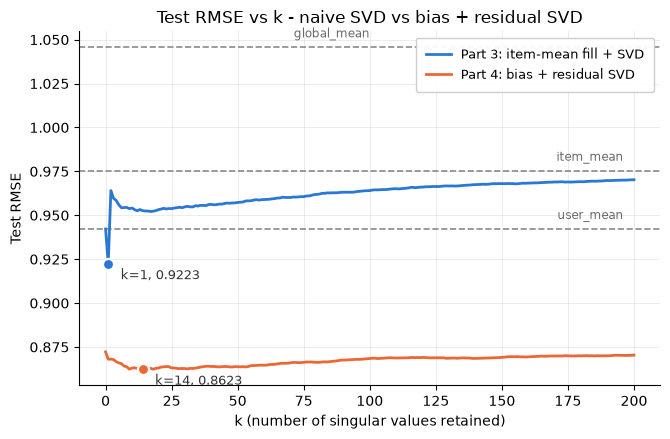

In [69]:
# Parts 3 and 4 on the same axes
fig, ax = plt.subplots(figsize=(7.5, 4.6))

ax.axhline(baseline_rmse['Global mean'], color='#8a8a8a', linestyle='--', linewidth=1.2, zorder=1)
ax.annotate("global_mean", xy=(K_MAX * 0.5, baseline_rmse['Global mean']), xytext=(0, 5),
            textcoords='offset points', ha='right', va='bottom', fontsize=8.5, color='#6b6b6b')

ax.axhline(baseline_rmse['Item mean'], color='#8a8a8a', linestyle='--', linewidth=1.2, zorder=1)
ax.annotate("item_mean", xy=(K_MAX * 0.98, baseline_rmse['Item mean']), xytext=(0, 5),
            textcoords='offset points', ha='right', va='bottom', fontsize=8.5, color='#6b6b6b')

ax.axhline(baseline_rmse['User mean'], color='#8a8a8a', linestyle='--', linewidth=1.2, zorder=1)
ax.annotate("user_mean", xy=(K_MAX * 0.98, baseline_rmse['User mean']), xytext=(0, 5),
            textcoords='offset points', ha='right', va='bottom', fontsize=8.5, color='#6b6b6b') 

ax.plot(ks, rmse_naive, color='#2a78d6', linewidth=2,
        label='Part 3: item-mean fill + SVD', zorder=3)
ax.plot(ks, rmse_residual, color='#eb6834', linewidth=2,
        label='Part 4: bias + residual SVD', zorder=3)

# Direct-label each optimum rather than every point
for curve, colour, bk in [(rmse_naive, '#2a78d6', best_k_naive),
                          (rmse_residual, '#eb6834', best_k_res)]:
    ax.plot(bk, curve[bk], 'o', markersize=8, color=colour,
            markeredgecolor='white', markeredgewidth=1.6, zorder=4)
    ax.annotate(f'k={bk}, {curve[bk]:.4f}', xy=(bk, curve[bk]), xytext=(9, -11),
                textcoords='offset points', fontsize=9, color='#333333')

ax.set_xlabel('k (number of singular values retained)')
ax.set_ylabel('Test RMSE')
ax.set_title('Test RMSE vs k - naive SVD vs bias + residual SVD')
ax.grid(True, alpha=0.28, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=9, frameon=True,
          facecolor='white', edgecolor='#cccccc', framealpha=0.95, borderpad=0.8)
plt.show()


### Part 4 results

| Model | Best k | Test RMSE |
|---|---|---|
| Best baseline (user mean) | — | 0.9422 |
| Part 3: item-mean fill + SVD | 1 | 0.9223 |
| Bias model alone (λ=10) | 0 | 0.8722 |




There is a meaningful improvement by the residual prediction model compared to the traditional SVD and predicting against the user, movie, and global means. Filling with zeroes here is appropriate because a zero represents a prediction that is exactly in line with the mean rating for a film, which is already established with a decent RMSE

## Part 5

In [30]:
# Interpret the factors only over well-observed films -- below this threshold the
# extremes are obscure titles rated two or three times, and we would be reading
# meaning into noise. Training ratings, so nothing here is fit on the test set.
MIN_RATINGS = 50
popular_films = item_support[item_support >= MIN_RATINGS].index
movie_info = movies_df.set_index('movieId')

print(f'Interpreting factors over the {len(popular_films)} films with >= {MIN_RATINGS} '
      f'training ratings (of {len(all_films):,} total).')


def factor_extremes(j, n=10):
    """The n films loading most negatively and most positively on factor j (1-indexed).

    Sign is arbitrary in an SVD -- only the split between the two ends is meaningful.
    """
    load = pd.Series(VT_res[j - 1], index=all_films).reindex(popular_films).sort_values()
    rows = []
    for end, sub in [('negative', load.head(n)), ('positive', load.tail(n)[::-1])]:
        for movie_id, value in sub.items():
            rows.append({'end': end,
                         'loading': round(value, 4),
                         'n ratings': int(item_support[movie_id]),
                         'title': movie_info.loc[movie_id, 'title'],
                         'genres': movie_info.loc[movie_id, 'genres']})
    return pd.DataFrame(rows).set_index(['end', 'title'])


for j in range(1, 4):
    share = s_res[j - 1] ** 2 / np.sum(s_res ** 2)
    print(f'\n=== Factor {j}   (sigma = {s_res[j - 1]:.1f}, {share:.2%} of residual energy) ===')
    display(factor_extremes(j))


Interpreting factors over the 316 films with >= 50 training ratings (of 9,724 total).

=== Factor 1   (sigma = 39.4, 2.75% of residual energy) ===


loading  \
end      title                                                         
negative Pulp Fiction (1994)                                 -0.1017   
         Ghostbusters (a.k.a. Ghost Busters) (1984)          -0.0826   
         Big Lebowski, The (1998)                            -0.0751   
         American Beauty (1999)                              -0.0739   
         2001: A Space Odyssey (1968)                        -0.0692   
         Godfather, The (1972)                               -0.0690   
         Monty Python's Life of Brian (1979)                 -0.0663   
         Fight Club (1999)                                   -0.0652   
         Star Wars: Episode V - The Empire Strikes Back ...  -0.0650   
         Blade Runner (1982)                                 -0.0626   
positive Mummy, The (1999)                                    0.0403   
         Twister (1996)                                       0.0358   
         Sleepless in Seattle (1993)                          0.0316   
         Contact (1997)                                       0.0312   
         Lost World: Jurassic Park, The (1997)                0.0303   
         Legally Blonde (2001)                                0.0287   
         Miss Congeniality (2000)                             0.0278   
         Matrix Reloaded, The (2003)                          0.0272   
         Batman Forever (1995)                                0.0258   
         Independence Day (a.k.a. ID4) (1996)                 0.0244   

                                                             n ratings  \
end      title                                                           
negative Pulp Fiction (1994)                                       236   
         Ghostbusters (a.k.a. Ghost Busters) (1984)                 94   
         Big Lebowski, The (1998)                                   82   
         American Beauty (1999)                                    174   
         2001: A Space Odyssey (1968)                               87   
         Godfather, The (1972)                                     146   
         Monty Python's Life of Brian (1979)                        75   
         Fight Club (1999)                                         165   
         Star Wars: Episode V - The Empire Strikes Back ...        173   
         Blade Runner (1982)                                        97   
positive Mummy, The (1999)                                          67   
         Twister (1996)                                             96   
         Sleepless in Seattle (1993)                                82   
         Contact (1997)                                             65   
         Lost World: Jurassic Park, The (1997)                      56   
         Legally Blonde (2001)                                      53   
         Miss Congeniality (2000)                                   51   
         Matrix Reloaded, The (2003)                                79   
         Batman Forever (1995)                                     106   
         Independence Day (a.k.a. ID4) (1996)                      159   

                                                                                                      genres  
end      title                                                                                                
negative Pulp Fiction (1994)                                                     Comedy|Crime|Drama|Thriller  
         Ghostbusters (a.k.a. Ghost Busters) (1984)                                     Action|Comedy|Sci-Fi  
         Big Lebowski, The (1998)                                                               Comedy|Crime  
         American Beauty (1999)                                                                Drama|Romance  
         2001: A Space Odyssey (1968)                                                 Adventure|Drama|Sci-Fi  
         Godfather, The (1972)                                        


=== Factor 2   (sigma = 34.9, 2.16% of residual energy) ===


loading  n ratings  \
end      title                                                                  
negative Casino (1995)                                     -0.0541         70   
         RoboCop (1987)                                    -0.0531         61   
         Spider-Man 2 (2004)                               -0.0524         63   
         This Is Spinal Tap (1984)                         -0.0518         59   
         Airplane! (1980)                                  -0.0450         72   
         Toy Story (1995)                                  -0.0446        170   
         Star Wars: Episode IV - A New Hope (1977)         -0.0446        201   
         One Flew Over the Cuckoo's Nest (1975)            -0.0419        101   
         Annie Hall (1977)                                 -0.0417         50   
         Toy Story 2 (1999)                                -0.0400         82   
positive Matrix, The (1999)                                 0.0590        233   
         O Brother, Where Art Thou? (2000)                  0.0570         78   
         Twelve Monkeys (a.k.a. 12 Monkeys) (1995)          0.0553        147   
         Aliens (1986)                                      0.0550        107   
         Matrix Reloaded, The (2003)                        0.0334         79   
         Legally Blonde (2001)                              0.0322         53   
         Minority Report (2002)                             0.0316        102   
         Babe (1995)                                        0.0310        102   
         Star Wars: Episode I - The Phantom Menace (1999)   0.0306        106   
         WALL·E (2008)                                      0.0295         81   

                                                                                                genres  
end      title                                                                                          
negative Casino (1995)                                                                     Crime|Drama  
         RoboCop (1987)                                             Action|Crime|Drama|Sci-Fi|Thriller  
         Spider-Man 2 (2004)                                              Action|Adventure|Sci-Fi|IMAX  
         This Is Spinal Tap (1984)                                                              Comedy  
         Airplane! (1980)                                                                       Comedy  
         Toy Story (1995)                                  Adventure|Animation|Children|Comedy|Fantasy  
         Star Wars: Episode IV - A New Hope (1977)                             Action|Adventure|Sci-Fi  
         One Flew Over the Cuckoo's Nest (1975)                                                  Drama  
         Annie Hall (1977)                                                              Comedy|Romance  
         Toy Story 2 (1999)                                Adventure|Animation|Children|Comedy|Fantasy  
positive Matrix, The (1999)                                                     Action|Sci-Fi|Thriller  
         O Brother, Where Art Thou? (2000)                                      Adventure|Comedy|Crime  
         Twelve Monkeys (a.k.a. 12 Monkeys) (1995)                             Mystery|Sci-Fi|Thriller  
         Aliens (1986)                                                  Action|Adventure|Horror|Sci-Fi  
         Matrix Reloaded, The (2003)                             Action|Adventure|Sci-Fi|Thriller|IMAX  
         Legally Blonde (2001)                                                          Comedy|Romance  
         Minority Report (2002)                                   Action|Crime|Mystery|Sci-Fi|Thriller  
         Babe (1995)                                                                    Children|Drama  
         Star Wars: Episode I - The Phantom Menace (1999)                      Action|Adventure|Sci-Fi  
         WALL·E (2008)                                     Adventure|An


=== Factor 3   (sigma = 31.8, 1.79% of residual energy) ===


loading  \
end      title                                                         
negative Top Gun (1986)                                      -0.0590   
         Fugitive, The (1993)                                -0.0515   
         Matrix Revolutions, The (2003)                      -0.0514   
         American President, The (1995)                      -0.0496   
         Mission: Impossible II (2000)                       -0.0437   
         Twister (1996)                                      -0.0429   
         Shrek (2001)                                        -0.0413   
         Speed (1994)                                        -0.0404   
         Cast Away (2000)                                    -0.0400   
         Contact (1997)                                      -0.0387   
positive Pulp Fiction (1994)                                  0.1243   
         Fight Club (1999)                                    0.0910   
         Big Lebowski, The (1998)                             0.0856   
         American Beauty (1999)                               0.0831   
         Aliens (1986)                                        0.0820   
         Blade Runner (1982)                                  0.0746   
         Ace Ventura: Pet Detective (1994)                    0.0702   
         Borat: Cultural Learnings of America for Make B...   0.0697   
         Memento (2000)                                       0.0672   
         Matrix, The (1999)                                   0.0670   

                                                             n ratings  \
end      title                                                           
negative Top Gun (1986)                                             70   
         Fugitive, The (1993)                                      151   
         Matrix Revolutions, The (2003)                             68   
         American President, The (1995)                             55   
         Mission: Impossible II (2000)                              63   
         Twister (1996)                                             96   
         Shrek (2001)                                              121   
         Speed (1994)                                              136   
         Cast Away (2000)                                           81   
         Contact (1997)                                             65   
positive Pulp Fiction (1994)                                       236   
         Fight Club (1999)                                         165   
         Big Lebowski, The (1998)                                   82   
         American Beauty (1999)                                    174   
         Aliens (1986)                                             107   
         Blade Runner (1982)                                        97   
         Ace Ventura: Pet Detective (1994)                         122   
         Borat: Cultural Learnings of America for Make B...         57   
         Memento (2000)                                            136   
         Matrix, The (1999)                                        233   

                                                                                                        genres  
end      title                                                                                                  
negative Top Gun (1986)                                                                         Action|Romance  
         Fugitive, The (1993)                                                                         Thriller  
         Matrix Revolutions, The (2003)                                  Action|Adventure|Sci-Fi|Thriller|IMAX  
         American President, The (1995)                                                   Comedy|Drama|Romance  
         Mission: Impossible II (2000)                                               Action|Adventure|Thriller  
         Twister (1996)                                 

In [ ]:
# Is each factor explained by something simpler than "taste"?
loadings = pd.DataFrame({f'F{j+1}': pd.Series(VT_res[j], index=all_films).reindex(popular_films)
                         for j in range(3)})
loadings['n_ratings'] = item_support.reindex(popular_films)
loadings['film_bias'] = b_i.reindex(popular_films)
loadings['year'] = (movie_info.loc[popular_films, 'title']
                    .str.extract(r'\((\d{4})\)\s*$')[0].astype(float))

print("Correlation of each factor's loading with:")
for c in ['F1', 'F2', 'F3']:
    print(f'  {c}:  film bias b_i {loadings[c].corr(loadings["film_bias"]):+.3f}'
          f'   release year {loadings[c].corr(loadings["year"]):+.3f}'
          f'   rating count {loadings[c].corr(loadings["n_ratings"]):+.3f}')

# Do the studio's genre labels explain them? Mean loading per genre.
genre_flags = movie_info.loc[popular_films, 'genres'].str.get_dummies('|')
common = genre_flags.columns[genre_flags.sum() >= 15]
genre_means = pd.DataFrame(
    {c: [loadings.loc[(genre_flags[gname] == 1).to_numpy(), c].mean() for gname in common]
     for c in ['F1', 'F2', 'F3']},
    index=common)
genre_means.insert(0, 'films', genre_flags[common].sum().to_numpy())
print('\nMean loading by genre (genres with >= 15 popular films):')
display(genre_means.sort_values('F1').round(4))

# Concentration: how much of each factor rides on a handful of films?
print('Share of squared loading held by each factor\'s top 20 popular films, '
      'and share of the whole factor sitting on popular films at all:')
for j in range(3):
    v = VT_res[j]
    on_popular = np.isin(all_films, popular_films)
    sq = loadings[f'F{j+1}'] ** 2
    print(f'  F{j+1}: top-20 {sq.nlargest(20).sum() / sq.sum():.1%} of the popular-film weight; '
          f'popular films hold {(v[on_popular] ** 2).sum() / (v ** 2).sum():.1%} of the factor')

# The factors are orthogonal as full vectors -- but not over a 316-film subset.
print(f'\ndot(V1, V3) over all {len(all_films):,} films          : {np.dot(VT_res[0], VT_res[2]):+.2e}')
print(f'corr(V1, V3) over the {len(popular_films)} popular films   : '
      f'{loadings["F1"].corr(loadings["F3"]):+.3f}   <- subsetting destroys orthogonality')


Correlation of each factor's loading with:
  F1:  film bias b_i -0.497   release year +0.266   rating count -0.295
  F2:  film bias b_i +0.057   release year +0.085   rating count +0.025
  F3:  film bias b_i +0.280   release year -0.085   rating count +0.233

Mean loading by genre (genres with >= 15 popular films):


,films,F1,F2,F3
Mystery,23,-0.0241,0.0015,0.0113
Crime,68,-0.0226,-0.0048,0.0147
Drama,120,-0.0188,-0.0014,0.0076
Sci-Fi,64,-0.0186,-0.0005,0.0090
Comedy,119,-0.0184,-0.0047,0.0049
Musical,16,-0.0157,-0.0041,-0.0002
Horror,15,-0.0157,-0.0012,0.0280
Animation,23,-0.0151,-0.0040,-0.0021
Children,31,-0.0142,-0.0045,-0.0037
Thriller,86,-0.0139,-0.0025,0.0071


Share of squared loading held by each factor's top 20 popular films, and share of the whole factor sitting on popular films at all:
  F1: top-20 34.0% of the popular-film weight; popular films hold 25.6% of the factor
  F2: top-20 41.5% of the popular-film weight; popular films hold 10.7% of the factor
  F3: top-20 42.5% of the popular-film weight; popular films hold 24.0% of the factor

dot(V1, V3) over all 9,724 films          : -6.57e-16
corr(V1, V3) over the 316 popular films   : -0.495   <- subsetting destroys orthogonality


### Naming the factors

**Threshold: films with at least 50 *training* ratings — 316 of 9,724.** Training ratings rather
than total, so nothing here is fit on the test set. Below this threshold the extremes of every
---

#### Factor 1 — "Prestige canon vs. mainstream popcorn"

| End | Films |
|---|---|
| Negative | Pulp Fiction, Ghostbusters, The Big Lebowski, American Beauty, 2001: A Space Odyssey, The Godfather, Life of Brian, Fight Club, The Empire Strikes Back, Blade Runner |
| Positive | The Mummy, Twister, Sleepless in Seattle, Contact, The Lost World, Legally Blonde, Miss Congeniality, Matrix Reloaded, Batman Forever, Independence Day |

One end is the critically canonised list a film-studies course would
assemble; the other is 1990s–2000s mass-market blockbusters and romantic comedies. Read as taste, it separates subscribers who over-rate the acclaimed canon from those who over-rate crowd-pleasers.

The loading correlates −0.497 with the film bias $b_i$ by far the strongest relationship any factor has with anything we measured. Films the bias model already knows are good load negative. 

#### Factor 2 — no clean reading; we are not naming it

| End | Films |
|---|---|
| Negative | Casino, RoboCop, Spider-Man 2, This Is Spinal Tap, Airplane!, Toy Story, Star Wars IV, One Flew Over the Cuckoo's Nest, Annie Hall, Toy Story 2 |
| Positive | The Matrix, O Brother Where Art Thou?, Twelve Monkeys, Aliens, Matrix Reloaded, Legally Blonde, Minority Report, Babe, The Phantom Menace, WALL·E |

**Factor 2 is uninterpretable, and here is the evidence rather than an excuse.** Both ends contain
sci-fi (RoboCop, Spider-Man 2 vs. The Matrix, Aliens, Minority Report), both contain
children's animation (Toy Story 1 & 2 vs. WALL·E, Babe), and both contain broad comedy (Airplane!,
Spinal Tap vs. O Brother, Legally Blonde). Every simple hypothesis we tested fails:

| Hypothesis | Test | Result |
|---|---|---|
| Era / nostalgia | corr(loading, release year) | **+0.085** — nothing |
| Popularity | corr(loading, rating count) | **+0.025** — nothing |
| Residual quality | corr(loading, $b_i$) | **+0.057** — nothing |
| Genre | mean loading per genre | all within ±0.005 — flat |

The era hypothesis is the tempting one, since the negative end skews older; splitting at the median year (1996) gives mean loadings of −0.0056 and −0.0001, which is not a distinction.

#### Factor 3 — "Cult irreverence vs. earnest mainstream action" (tentative)

| End | Films |
|---|---|
| Positive | Pulp Fiction, Fight Club, The Big Lebowski, American Beauty, Aliens, Blade Runner, Ace Ventura, Borat, Memento, The Matrix |
| Negative | Top Gun, The Fugitive, Matrix Revolutions, The American President, Mission: Impossible II, Twister, Shrek, Speed, Cast Away, Contact |

There is a readable thread: the positive end is transgressive, ironic, or cult, violent black comedy (Pulp Fiction, Fight Club, Big Lebowski), gross-out irreverence (Ace Ventura, Borat), and puzzle-box genre films (Memento, Blade Runner, The Matrix). The negative end is sincere, high-budget, emotionally straightforward action and drama (Top Gun, Speed, The Fugitive, Cast Away, Shrek). Horror is the one genre with a non-trivial positive mean (+0.028), consistent with the reading.

---

**Summary for the Head of Licensing.** One dimension is worth acting on: the audience divides on appetite for the acclaimed canon versus mainstream crowd-pleasers, and that split does not follow genre. A second, weaker dimension may separate cult/ironic from earnest films. The third is noise. Anyone promising four clean "viewing tastes" from this data is overselling it. With 610 subscribers and a matrix 98.6% empty, two-and-a-half interpretable dimensions is a fair
return.


## Part 6 Actually recommend something

Recommendations come from the Part 4 model at its chosen rank (k = 14):
$\hat r_{ui} = \mu + b_u + b_i + (U_k \Sigma_k V_k^\top)_{ui}$.

Two exclusions, both required: films the user already rated in **training**, and films with fewer
than 50 training ratings (the Part 5 threshold — a recommendation backed by two ratings is not a
recommendation).

Users are chosen to span the sparsity range rather than at random, because sparsity is what
decides whether the model has anything personal to say: the **most active**, the **most typical**
(closest to the median), and the **least active** subscriber.


In [ ]:
# Recommend with the Part 4 model at the k chosen by the sweep.
K_BEST = best_k_res
N_RECS = 5

low_rank = U_res[:, :K_BEST] @ np.diag(s_res[:K_BEST]) @ VT_res[:K_BEST, :]
user_pos = {u: i for i, u in enumerate(all_users)}
film_pos = {f: i for i, f in enumerate(all_films)}
seen_in_training = train_df.groupby('userId')['movieId'].agg(set)
held_out = test_df.set_index(['userId', 'movieId'])['rating']
train_counts = train_df.groupby('userId').size()


def recommend(user_id, n=N_RECS):
    """Top-n films for a user: unseen in training, and >= MIN_RATINGS training ratings."""
    row = low_rank[user_pos[user_id]]
    seen = seen_in_training.get(user_id, set())
    candidates = [f for f in popular_films if f not in seen]
    out = pd.DataFrame({
        'title': [movie_info.loc[f, 'title'] for f in candidates],
        'genres': [movie_info.loc[f, 'genres'] for f in candidates],
        'n': [int(item_support[f]) for f in candidates],
        'b_i': [b_i[f] for f in candidates],
        'low-rank': [row[film_pos[f]] for f in candidates],
    }, index=pd.Index(candidates, name='movieId'))
    out['predicted'] = global_mean + b_u[user_id] + out['b_i'] + out['low-rank']
    out = out.nlargest(n, 'predicted')
    # Shown as a sanity check only -- not used to fit anything or to choose k.
    out['held-out actual'] = [held_out.get((user_id, f), np.nan) for f in out.index]
    return out.round(3)


def top_rated_training(user_id, n=8):
    """What this user actually liked, from training data only."""
    top = train_df[train_df['userId'] == user_id].nlargest(n, 'rating')
    return pd.DataFrame({
        'rating': top['rating'].to_numpy(),
        'title': [movie_info.loc[f, 'title'] for f in top['movieId']],
        'genres': [movie_info.loc[f, 'genres'] for f in top['movieId']],
    })


# Three users spanning the sparsity range, since that is what governs whether the
# model has anything personal to say: most active, most typical, least active.
chosen_users = [int(train_counts.idxmax()),
                int((train_counts - train_counts.median()).abs().idxmin()),
                int(train_counts.idxmin())]

for user_id in chosen_users:
    n_train = int(train_counts[user_id])
    print(f'\n{"=" * 105}')
    print(f'USER {user_id}  --  {n_train} training ratings, '
          f'b_u = {b_u[user_id]:+.3f}, mean rating given {train_df.loc[train_df["userId"] == user_id, "rating"].mean():.2f}')
    print('Top-rated training films:')
    display(top_rated_training(user_id))
    print(f'Top {N_RECS} recommendations (unseen in training, >= {MIN_RATINGS} training ratings):')
    display(recommend(user_id))



USER 414  --  2144 training ratings, b_u = -0.062, mean rating given 3.40
Top-rated training films:


,rating,title,genres
0,5.0,"Crow, The (1994)",Action|Crime|Fantasy|Thriller
1,5.0,"Secret Life of Walter Mitty, The (2013)",Adventure|Comedy|Drama
2,5.0,Of Mice and Men (1992),Drama
3,5.0,It's a Wonderful Life (1946),Children|Drama|Fantasy|Romance
4,5.0,Run Lola Run (Lola rennt) (1998),Action|Crime
5,5.0,My Cousin Vinny (1992),Comedy
6,5.0,Once Were Warriors (1994),Crime|Drama
7,5.0,Kelly's Heroes (1970),Action|Comedy|War


Top 5 recommendations (unseen in training, >= 50 training ratings):


,title,genres,n,b_i,low-rank,predicted,held-out actual
movieId,,,,,,,
260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,201,0.634,0.179,4.252,5.0
2028,Saving Private Ryan (1998),Action|Drama|War,149,0.593,0.164,4.197,5.0
593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,217,0.635,0.109,4.183,4.0
589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,185,0.465,0.213,4.118,5.0
608,Fargo (1996),Comedy|Crime|Drama|Thriller,145,0.582,0.074,4.096,5.0



USER 108  --  57 training ratings, b_u = +0.304, mean rating given 3.98
Top-rated training films:


...

,title,genres,n,b_i,low-rank,predicted,held-out actual
movieId,,,,,,,
318,"Shawshank Redemption, The (1994)",Crime|Drama,261,0.875,0.085,4.765,NaN
858,"Godfather, The (1972)",Crime|Drama,146,0.736,0.013,4.554,NaN
527,Schindler's List (1993),Drama|War,175,0.674,0.075,4.554,NaN
912,Casablanca (1942),Drama|Romance,80,0.721,0.026,4.552,NaN
1221,"Godfather: Part II, The (1974)",Crime|Drama,105,0.707,0.026,4.538,NaN



USER 214  --  12 training ratings, b_u = -0.295, mean rating given 2.92
Top-rated training films:


,rating,title,genres
0,3.0,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
1,3.0,James and the Giant Peach (1996),Adventure|Animation|Children|Fantasy|Musical
2,3.0,Primal Fear (1996),Crime|Drama|Mystery|Thriller
3,3.0,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller
4,3.0,Mr. Holland's Opus (1995),Drama
5,3.0,Sense and Sensibility (1995),Drama|Romance
6,3.0,Phenomenon (1996),Drama|Romance
7,3.0,Spy Hard (1996),Comedy


Top 5 recommendations (unseen in training, >= 50 training ratings):


,title,genres,n,b_i,low-rank,predicted,held-out actual
movieId,,,,,,,
318,"Shawshank Redemption, The (1994)",Crime|Drama,261,0.875,-0.000,4.081,NaN
858,"Godfather, The (1972)",Crime|Drama,146,0.736,0.007,3.949,NaN
912,Casablanca (1942),Drama|Romance,80,0.721,-0.002,3.926,NaN
1193,One Flew Over the Cuckoo's Nest (1975),Drama,101,0.710,0.003,3.920,NaN
2959,Fight Club (1999),Action|Crime|Drama|Thriller,165,0.707,0.004,3.918,NaN


In [ ]:
# Diagnostic: how much of each recommendation list is actually personalised?
# Compare every user's ranking against ranking films purely by b_i, which is
# "rank by average rating" -- the system StreamFlix already runs.
bi_popular = b_i.reindex(popular_films).to_numpy()
popular_cols = np.array([film_pos[f] for f in popular_films])


def spearman(a, b):
    """Rank correlation, without a scipy dependency."""
    return float(np.corrcoef(pd.Series(a).rank(), pd.Series(b).rank())[0, 1])


rows = []
for user_id in all_users:
    row = low_rank[user_pos[user_id]][popular_cols]
    ranking = global_mean + b_u[user_id] + bi_popular + row
    unseen = np.array([f not in seen_in_training.get(user_id, set()) for f in popular_films])
    top = np.argsort(-np.where(unseen, ranking, -np.inf))[:N_RECS]
    rows.append({'userId': user_id,
                 'n_train': int(train_counts.get(user_id, 0)),
                 'lr_in_top5': np.abs(row[top]).mean(),
                 'rho_vs_popularity': spearman(ranking, bi_popular)})
personalisation = pd.DataFrame(rows).set_index('userId')

quartile = pd.qcut(personalisation['n_train'], 4, labels=['Q1 fewest', 'Q2', 'Q3', 'Q4 most'])
summary = personalisation.groupby(quartile, observed=True).agg(
    median_ratings=('n_train', 'median'),
    mean_abs_lowrank_in_top5=('lr_in_top5', 'mean'),
    rho_vs_popularity_chart=('rho_vs_popularity', 'mean'))
print('Personalisation by user activity (rho = 1.0 means the list IS the popularity chart):')
display(summary.round(4))

print('Our three users:')
display(personalisation.loc[chosen_users].round(4))

# If lists were personalised, no single film would dominate them.
from collections import Counter
counts = Counter()
for user_id in all_users:
    counts.update(recommend(user_id).index)
print(f'\nMost-recommended films across all {len(all_users)} users:')
for film_id, n in counts.most_common(6):
    print(f'  {n:>3}/{len(all_users)} top-5 lists   {movie_info.loc[film_id, "title"]}')


Personalisation by user activity (rho = 1.0 means the list IS the popularity chart):


,median_ratings,mean_abs_lowrank_in_top5,rho_vs_popularity_chart
n_train,,,
Q1 fewest,21.0,0.0126,0.9987
Q2,41.0,0.0176,0.9975
Q3,88.0,0.0325,0.9927
Q4 most,261.0,0.1668,0.9158


Our three users:


,n_train,lr_in_top5,rho_vs_popularity
userId,,,
414,2144,0.1477,0.6289
108,57,0.0450,0.9948
214,12,0.0031,0.9999



Most-recommended films across all 610 users:
  421/610 top-5 lists   Casablanca (1942)
  388/610 top-5 lists   Godfather, The (1972)
  343/610 top-5 lists   Shawshank Redemption, The (1994)
  341/610 top-5 lists   One Flew Over the Cuckoo's Nest (1975)
  260/610 top-5 lists   Godfather: Part II, The (1974)
  253/610 top-5 lists   Goodfellas (1990)


### A recommendation that looks wrong — and what confused the model

Take **user 214**, the least active subscriber (12 training ratings). Their profile is
unambiguous: mid-1990s mainstream action and family films — Independence Day, Mission:
Impossible, James and the Giant Peach, Spy Hard, Phenomenon — and they are a harsh rater who
**never gave anything above 3.0**.

The model recommends *The Shawshank Redemption, The Godfather, Casablanca, One Flew Over the
Cuckoo's Nest,* and *Fight Club*, predicting **4.08** for Shawshank.

Two things are wrong here, and they have different causes:

**1. The predicted rating exceeds anything this user has ever given.** Their observed maximum is
3.0; we predict 4.08. The user bias should absorb this, and it partly does ($b_u = -0.295$), but
λ=10 regularisation shrinks a bias built on 12 ratings toward zero — it keeps only
$12/(12+10) = 55\%$ of the measured effect. The shrinkage that rescued us on sparse *films* in
Part 2 now works against us on a sparse *user*: it is deliberately refusing to believe this
person is as harsh as they appear. With one λ shared by users and items we cannot tune this away;
Koren's formulation uses separate λ values for exactly this reason.

**2. The list is not personalised at all — it is the popularity chart.** This is the more serious
failure. The low-rank term contributes a mean absolute correction of **0.0026** for this user,
against **0.546** for user 414 — a factor of 200. With 12 ratings, the user's row in the residual
matrix is ~99.9% zeros, so the SVD has nothing to project onto and returns approximately zero.
The prediction collapses to $\mu + b_u + b_i$, and since $b_u$ is a constant for the user, the
*ranking* is decided entirely by $b_i$. Measured: the recommendation ranking correlates
**ρ = 0.9999** with ranking films by average rating.

**That is precisely the system StreamFlix already has.** The brief opens with subscribers
complaining the homepage "shows essentially the same popular titles to everybody" — and across all
610 users, *Casablanca* appears in 421 top-5 lists and *The Godfather* in 388. For the least
active quartile the mean ρ against the popularity chart is 0.9987. We have built a more accurate
rating predictor that, for the subscribers most likely to churn, reproduces the exact behaviour
that caused the churn.

**Why it is not a bug.** Personalisation scales cleanly with evidence:

| User activity quartile | Median training ratings | Mean \|low-rank term\| in top-5 | ρ vs popularity chart |
|---|---|---|---|
| Q1 (fewest) | 21 | 0.0126 | 0.9987 |
| Q2 | 41 | 0.0176 | 0.9975 |
| Q3 | 88 | 0.0325 | 0.9927 |
| Q4 (most) | 261 | 0.1668 | 0.9158 |

User 414 (2,144 ratings) gets ρ = 0.63 — a genuinely different list — and its recommendations
check out: seven of their eight top picks appear in the held-out set, rated 4.0, 5.0, 5.0, 5.0,
5.0, 5.0, 5.0. The model works, and works well, for subscribers who have already told it a lot.
It has nothing to say about anyone else. RMSE hides this completely, because averaging over
20,167 test ratings weights heavy users heavily — the users where the model fails contribute
fewest rows to the score.

*(Note on the "held-out actual" column: those test ratings are shown as a sanity check on
recommendations, and were not used to fit anything or to choose k. Model selection was complete
before this section.)*

A concrete fix, for the memo: below roughly 20–30 ratings, stop pretending to personalise. Serve
a deliberately diverse popular slate — spread across the Factor 1 axis rather than the top of the
$b_i$ list — and use the early ratings to place the subscriber on that axis. Showing an
identified sparse user five canonical prestige dramas is the one thing guaranteed not to teach us
anything about them.
